<a href="https://colab.research.google.com/github/clobos/Thales_2026/blob/main/Tutorial_2_Regressoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Atenção:** Para editar e salvar seu trabalho, você precisa primeiro criar sua própria cópia deste *notebook*.

Siga os passos:

1.   Clique em *Arquivo* no menu superior.
2.   Selecione S*alvar uma cópia no Drive*. Uma nova aba será aberta com sua própria versão editável.

# **Tutorial 2: Regressões**

Este tutorial é baseado nos exemplos do livro *An Introduction to Statistical Learning*, de Gareth James, Daniela Witten, Trevor Hastie e Rob Tibshirani (https://www.statlearning.com/) e no tutorial *Checking model assumption - linear models* do pacote `performance`, de Daniel Lüdecke et al. (https://easystats.github.io/performance/articles/check_model.html).

## Bibliotecas

A função `library()` é usada para carregar *bibliotecas* (ou *pacotes*), ou seja, conjuntos de funções e conjuntos de dados que não estão incluídos na versão básica do `R`. Funções básicas que realizam regressão linear por mínimos quadrados e outras análises simples já vêm com o `R`, mas funções mais específicas exigem bibliotecas adicionais.  
Aqui, carregamos o pacote `MASS`, que é uma grande coleção de conjuntos de dados e funções. Também carregamos o pacote `ISLR2`, que inclui os conjuntos de dados utilizados no tutorial anterior. Mas, antes de carregá-los, precisamos instalá-los com a função `install.packages()`, e aproveitamos para instalar os demais pacotes que utilizaremos neste tutorial (esse processo pode demorar alguns minutos):


In [1]:
install.packages("MASS")
install.packages("ISLR2")
install.packages("ggplot2")
install.packages("lmtest")
install.packages("car")

library(MASS)
library(ISLR2)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’



Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston




## Regressão Linear Simples

Já vimos no Tutorial 1 que a biblioteca `ISLR2` contém o conjunto de dados `Boston`, que registra `medv` (valor mediano da casa) de $506$ setores censitários em Boston. Nosso objetivo será prever `medv` utilizando $12$ preditores (variáveis), como `rmvar` (número médio de cômodos por casa), `age` (proporção de unidades ocupadas por proprietários construídas antes de 1940) e `lstat` (percentual de domicílios com baixo status socioeconômico).


In [2]:
head(Boston)



,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.00632,18,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
6,0.02985,0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7


Para saber mais sobre o conjunto de dados, podemos digitar `?Boston`.

Vamos começar utilizando a função `lm()` para ajustar um modelo de regressão linear simples, com `medv` como variável resposta e `lstat` como preditor. A sintaxe básica é `lm(y ~ x, data)`, onde `y` é a variável resposta, `x` é o preditor e `data` é o conjunto de dados onde essas duas variáveis estão armazenadas. ***O seguinte exemplo resulta e um erro:***


In [9]:
# lm.fit <- lm(medv ~ lstat)



... o *script* acima gera um erro porque o `R` não sabe onde encontrar as variáveis `medv` e `lstat`. O *script* a seguir diz ao `R` que as variáveis estão em `Boston`. Se usarmos o comando `attach(Boston)`, a primeira linha funciona corretamente, pois o `R` agora reconhece as variáveis (note que aqui nomeamos nosso modelo de `lm.fit`, mas poderiamos ter escolhido qualquer outro nome):



In [40]:
lm.fit <- lm(medv ~ lstat, data = Boston) # Ajusta o modelo linear `medv` em função de `lstat`
attach(Boston) # Torna as variáveis do dataset `Boston` disponíveis diretamente
lm.fit <- lm(medv ~ lstat) # Ajusta o modelo novamente, agora sem precisar referenciar 'data' (devido ao `attach(Boston)`)


The following objects are masked from Boston (pos = 8):

    age, chas, crim, dis, indus, lstat, medv, nox, ptratio, rad, rm,
    tax, zn





Call:
lm(formula = medv ~ lstat)

Residuals:
    Min      1Q  Median      3Q     Max 
-15.168  -3.990  -1.318   2.034  24.500 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 34.55384    0.56263   61.41   <2e-16 ***
lstat       -0.95005    0.03873  -24.53   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.216 on 504 degrees of freedom
Multiple R-squared:  0.5441,	Adjusted R-squared:  0.5432 
F-statistic: 601.6 on 1 and 504 DF,  p-value: < 2.2e-16


Se digitarmos `lm.fit`, algumas informações básicas sobre o modelo serão exibidas. Para obter informações mais detalhadas, usamos `summary(lm.fit)`. Isso nos fornece os valores de $p$ e os erros padrão para os coeficientes, assim como as estatísticas $R^2$ e $F$ para o modelo. (A estatística $F$ em um modelo linear é uma medida que avalia a significância global do modelo de regressão. Em outras palavras, ela testa a hipótese nula de que todos os coeficientes de regressão no modelo são iguais a zero.)



In [41]:
lm.fit


Call:
lm(formula = medv ~ lstat)

Coefficients:
(Intercept)        lstat  
      34.55        -0.95  


In [42]:
summary(lm.fit)


Call:
lm(formula = medv ~ lstat)

Residuals:
    Min      1Q  Median      3Q     Max 
-15.168  -3.990  -1.318   2.034  24.500 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 34.55384    0.56263   61.41   <2e-16 ***
lstat       -0.95005    0.03873  -24.53   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.216 on 504 degrees of freedom
Multiple R-squared:  0.5441,	Adjusted R-squared:  0.5432 
F-statistic: 601.6 on 1 and 504 DF,  p-value: < 2.2e-16


Podemos usar a função `names()` para descobrir quais outras informações estão armazenadas em `lm.fit`. Embora possamos extrair essas informações pelo nome, como por exemplo, `lm.fit$coefficients`, podemos também usar certas funções específicas como `coef()` para acessá-las:



In [43]:
names(lm.fit)


[1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "xlevels"       "call"          "terms"         "model"

Para obter um intervalo de confiança para as estimativas dos coeficientes, podemos usar o comando `confint()`:



In [44]:
lm.fit$coefficients


(Intercept)       lstat 
 34.5538409  -0.9500494

In [45]:
coef(lm.fit)


(Intercept)       lstat 
 34.5538409  -0.9500494

In [46]:
confint(lm.fit)



,2.5 %,97.5 %
(Intercept),33.448457,35.6592247
lstat,-1.026148,-0.8739505


A função `predict()` pode ser usada para produzir intervalos de confiança e intervalos de predição para a previsão de `medv` para um dado valor de `lstat`:



In [47]:
predict(lm.fit, data.frame(lstat = (c(5, 10, 15))), interval = "confidence") # Calcula valores previstos com intervalo de confiança para os valores 5, 10 e 15



,fit,lwr,upr
1,29.80359,29.00741,30.59978
2,25.05335,24.47413,25.63256
3,20.30310,19.73159,20.87461


In [48]:
predict(lm.fit, data.frame(lstat = (c(5, 10, 15))), interval = "prediction") # Calcula valores previstos com intervalo de predição para os valores 5, 10 e 15


,fit,lwr,upr
1,29.80359,17.565675,42.04151
2,25.05335,12.827626,37.27907
3,20.30310,8.077742,32.52846


Por exemplo, o intervalo de confiança de 95\% associado a um valor de `lstat` igual a $10$ é $24.47$--$25.63$, e o intervalo de predição de 95\% é $12.83$--$37.28$. Como esperado, os intervalos de confiança e de predição estão centrados no mesmo ponto (um valor previsto de $25.05$ para `medv` quando `lstat` é igual a $10$), mas os intervalos de predição são consideravelmente mais largos. Em geral, o intervalo de confiança lida com a incerteza na estimativa do parâmetro *médio da população* e o intervalo de predição lida com a incerteza na previsão de um *único ponto* de dados futuro.

Agora, vamos plotar `medv` e `lstat` junto com a linha de regressão dos mínimos quadrados usando as funções `plot()` e `abline()`:


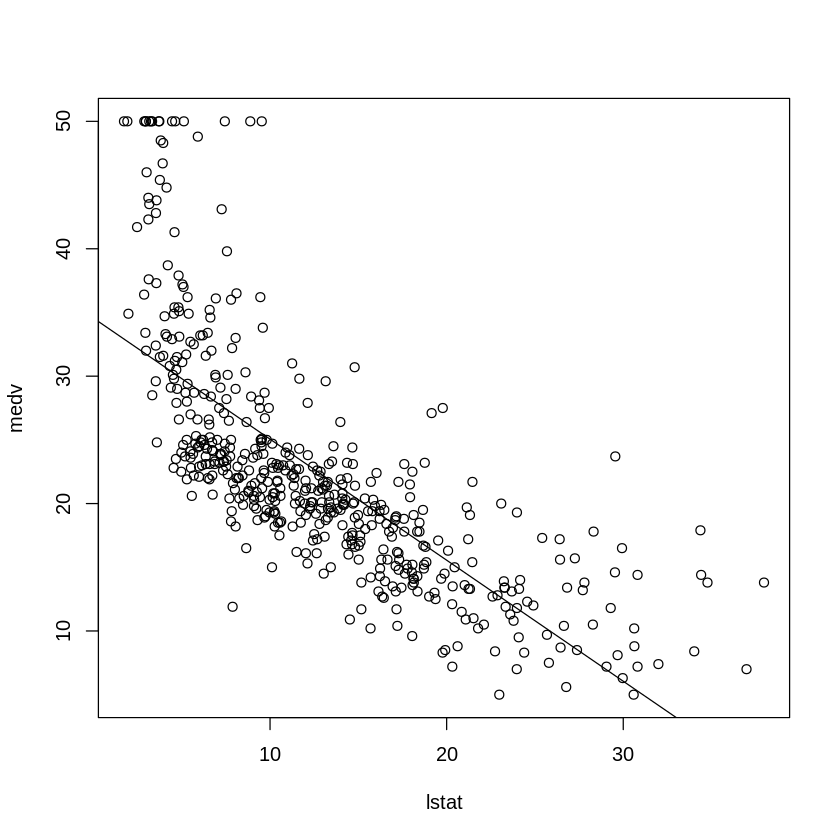

In [8]:
plot(lstat, medv) # Gera o gráfico de dispersão entre as variáveis
abline(lm.fit) # Adiciona a reta de regressão ajustada ao gráfico


Há algumas evidências de não linearidade na relação entre `lstat` e `medv`. Vamos explorar essa questão mais adiante neste tutorial.

A função `abline()` pode ser usada para desenhar qualquer linha, não apenas a linha de regressão dos mínimos quadrados.
Para desenhar uma linha com intercepto `a` e inclinação `b`, digitamos `abline(a, b)`. Abaixo, experimentamos algumas configurações adicionais para plotar linhas e pontos.
O comando `lwd = 3` aumenta a largura da linha de regressão por um fator de 3; isso também funciona para as funções `plot()` e `lines()`. Podemos também usar a opção `pch` para criar diferentes símbolos de plotagem:


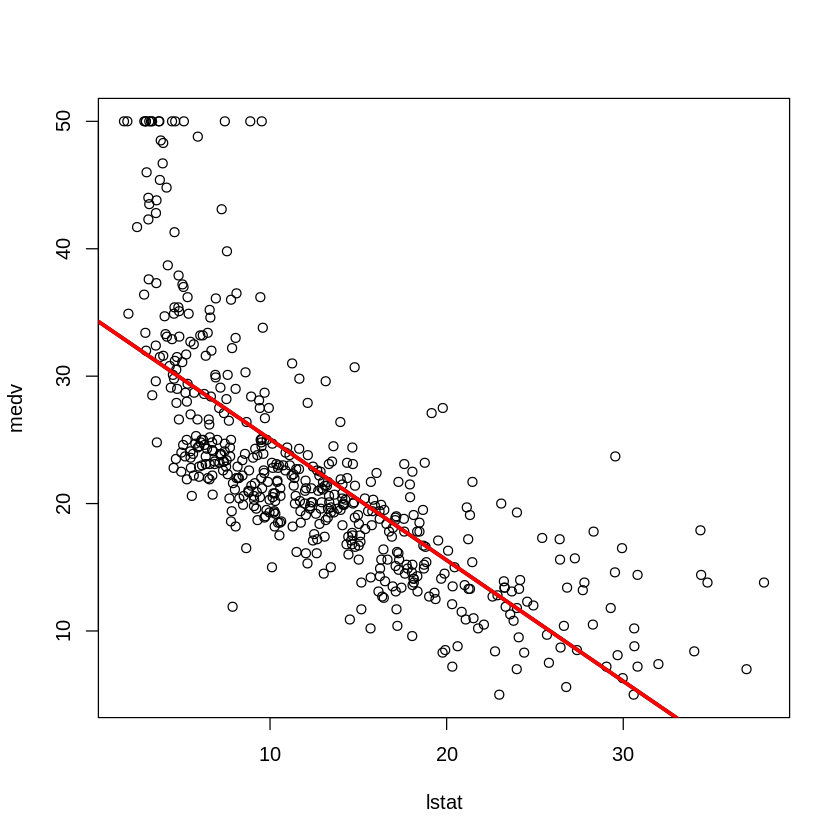

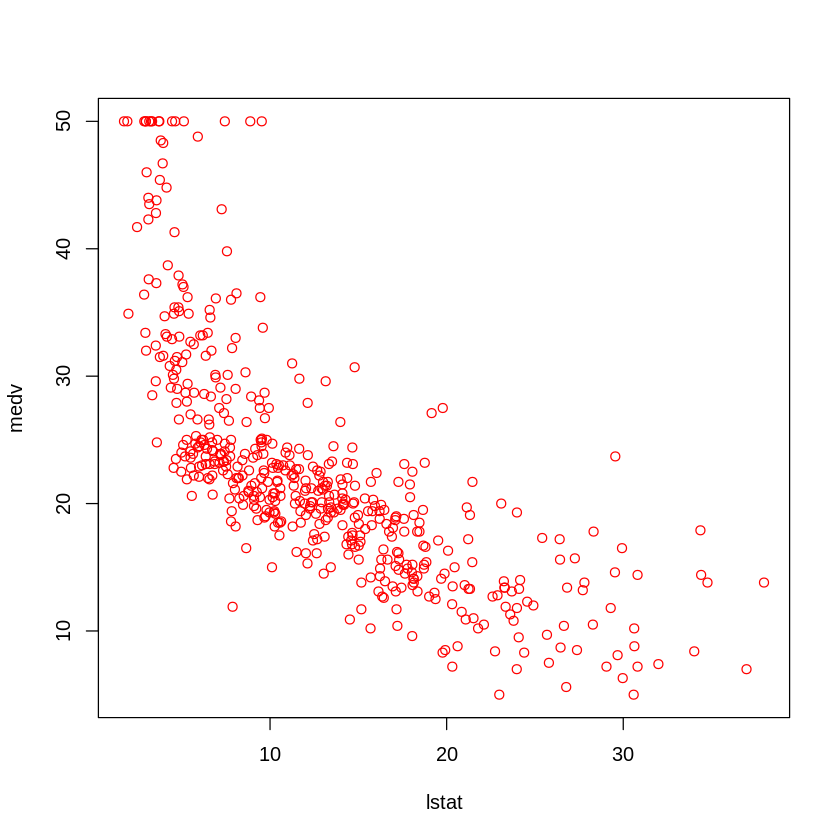

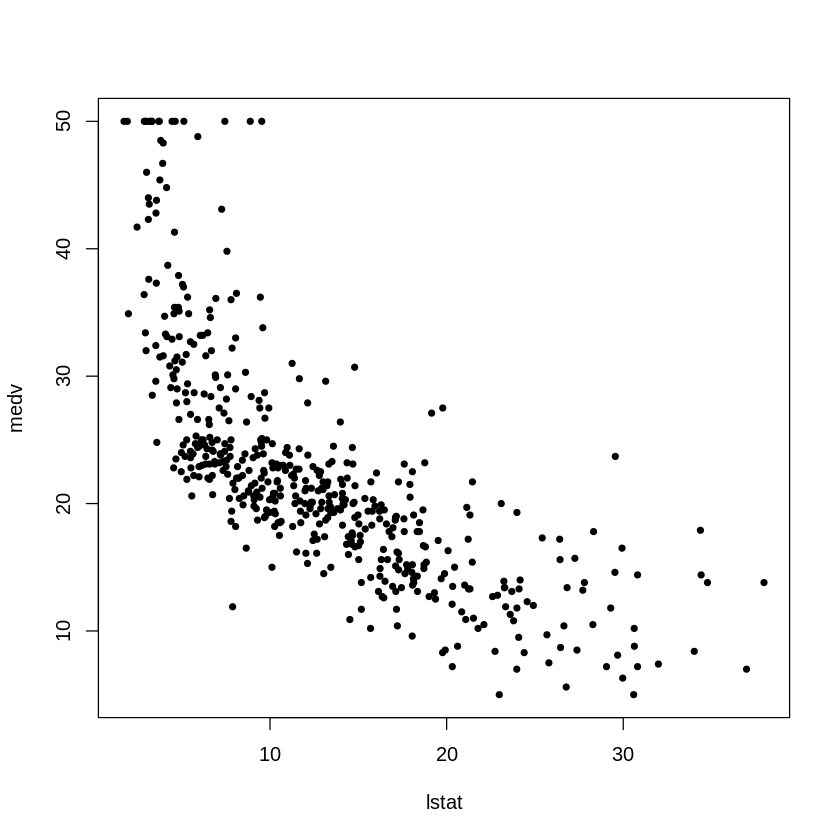

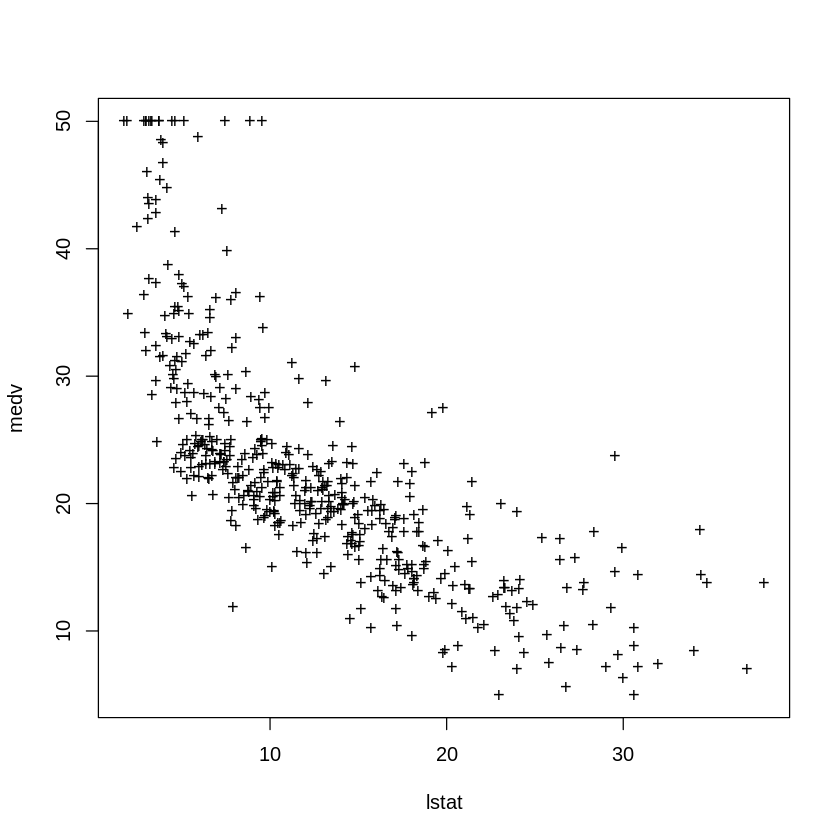

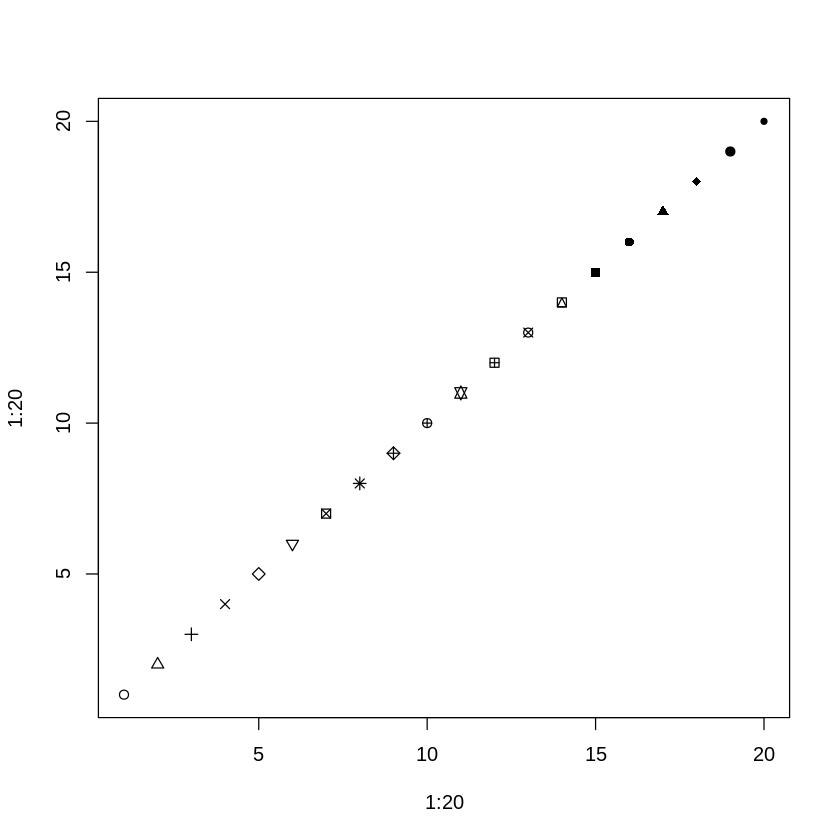

In [10]:
plot(lstat, medv) # Gera o gráfico de dispersão padrão
abline(lm.fit, lwd = 3) # Adiciona a linha de regressão com espessura triplicada
abline(lm.fit, lwd = 3, col = "red") # Adiciona a linha de regressão na cor vermelha
plot(lstat, medv, col = "red") # Cria o gráfico com os pontos (círculos) em vermelho
plot(lstat, medv, pch = 20) # Altera o símbolo dos pontos para círculos preenchidos pequenos
plot(lstat, medv, pch = "+") # Altera o símbolo dos pontos para o caractere de soma
plot(1:20, 1:20, pch = 1:20) # Cria um guia visual exibindo os símbolos disponíveis de 1 a 20

Em seguida, examinamos alguns gráficos de diagnóstico para nosso modelo linear. Quatro gráficos de diagnóstico são produzidos automaticamente ao aplicar a função `plot()` diretamente à saída de `lm()`. Em geral, esse comando produzirá um gráfico por vez, e pressionar *Enter* gerará o próximo gráfico. No entanto, é frequentemente conveniente visualizar todos os quatro gráficos ao mesmo tempo. Podemos fazer isso usando as funções `par()` e `mfrow()`, que instruem o `R` a dividir a tela de exibição em painéis separados para que múltiplos gráficos possam ser vistos simultaneamente. Por exemplo, `par(mfrow = c(2, 2))` divide a região de plotagem em uma grade $2 \times 2$ de painéis:



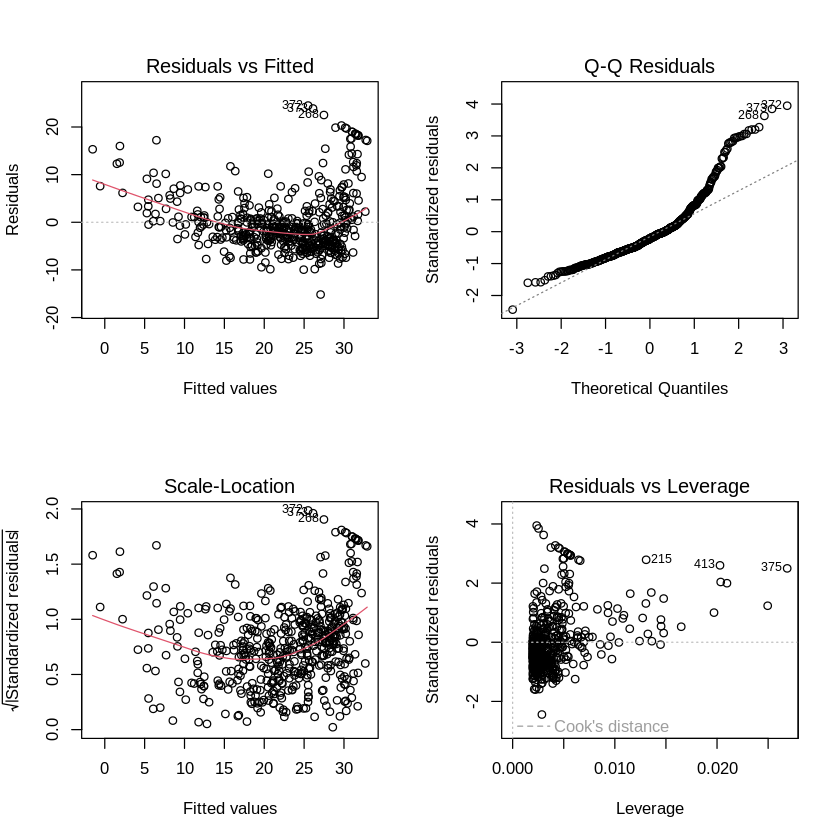

In [11]:
par(mfrow = c(2, 2))
plot(lm.fit)


Alternativamente, podemos calcular os resíduos de um ajuste de regressão linear usando a função `residuals()`. Já a função `rstudent()` retornará os resíduos *studentizados* (i.e., uma versão "ajustada" dos resíduos que facilita a comparação entre eles, levando em consideração a influência da própria observação na estimativa do modelo, o que ajuda a identificar *outliers*). Podemos usar essas funções para plotar os resíduos do modelo contra os valores ajustados:



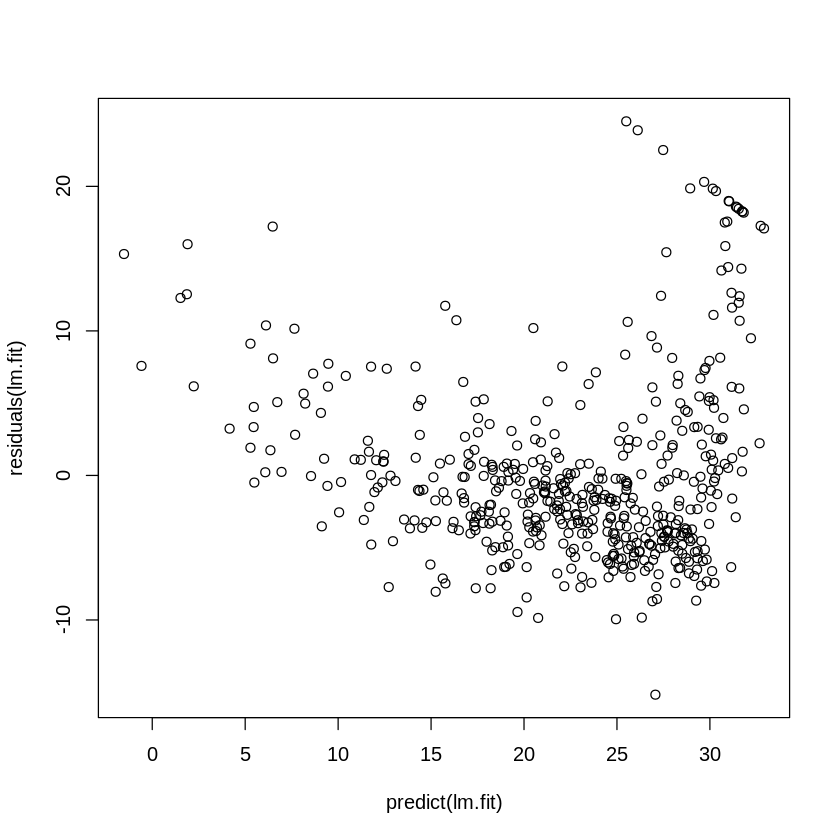

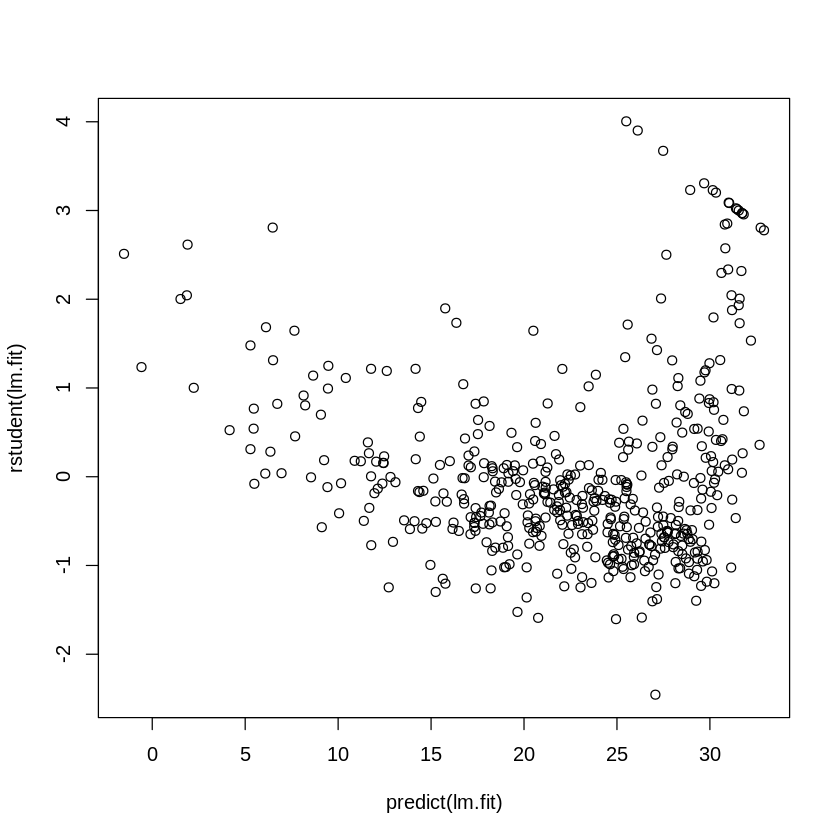

In [12]:
plot(predict(lm.fit), residuals(lm.fit))
plot(predict(lm.fit), rstudent(lm.fit))


## Regressão Linear Múltipla

Para ajustar um modelo de regressão linear múltipla usando o método dos mínimos quadrados, usamos novamente a função `lm()`. A sintaxe `lm(y ~ x1 + x2 + x3)` é usada para ajustar um modelo com três preditores, por exemplo. A seguir, utilizamos dois preditores, `lstat` e `age`:


In [13]:
lm.fit <- lm(medv ~ lstat + age, data = Boston)
summary(lm.fit)



Call:
lm(formula = medv ~ lstat + age, data = Boston)

Residuals:
    Min      1Q  Median      3Q     Max 
-15.981  -3.978  -1.283   1.968  23.158 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 33.22276    0.73085  45.458  < 2e-16 ***
lstat       -1.03207    0.04819 -21.416  < 2e-16 ***
age          0.03454    0.01223   2.826  0.00491 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.173 on 503 degrees of freedom
Multiple R-squared:  0.5513,	Adjusted R-squared:  0.5495 
F-statistic:   309 on 2 and 503 DF,  p-value: < 2.2e-16


No entanto, o conjunto de dados `Boston` contém $12$ variáveis, e seria um pouco trabalhoso ter que digitar todas elas em nosso modelo de regressão... Em vez disso, podemos usar a seguinte forma abreviada:



In [14]:
lm.fit <- lm(medv ~ ., data = Boston) # Todas as variáveis em `Boston` servem como preditoras
summary(lm.fit)



Call:
lm(formula = medv ~ ., data = Boston)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.1304  -2.7673  -0.5814   1.9414  26.2526 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  41.617270   4.936039   8.431 3.79e-16 ***
crim         -0.121389   0.033000  -3.678 0.000261 ***
zn            0.046963   0.013879   3.384 0.000772 ***
indus         0.013468   0.062145   0.217 0.828520    
chas          2.839993   0.870007   3.264 0.001173 ** 
nox         -18.758022   3.851355  -4.870 1.50e-06 ***
rm            3.658119   0.420246   8.705  < 2e-16 ***
age           0.003611   0.013329   0.271 0.786595    
dis          -1.490754   0.201623  -7.394 6.17e-13 ***
rad           0.289405   0.066908   4.325 1.84e-05 ***
tax          -0.012682   0.003801  -3.337 0.000912 ***
ptratio      -0.937533   0.132206  -7.091 4.63e-12 ***
lstat        -0.552019   0.050659 -10.897  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Podemos verificar quais são os componentes individuais de `summary()` digitando `?summary.lm`. Entre eles, `summary(lm.fit)$r.sq` retorna o $R^2$ e `summary(lm.fit)$sigma` retorna o *Erro Padrão Residual* (i.e., essencialmente, o desvio padrão típico dos resíduos).

A função `vif()`, parte do pacote `car`, pode ser usada para calcular os fatores de inflação de variância (*Variance Inflation Factor*), que quantifica o quanto a variância do coeficiente de um preditor é aumentada devido à *multicolinearidade* (falaremos mais sobre isso mais abaixo). No entanto, o pacote `car` não faz parte da instalação padrão do `R`, então ele deve ser baixado na primeira vez que for utilizado:


In [15]:
library(car)
vif(lm.fit)


Loading required package: carData



crim       zn    indus     chas      nox       rm      age      dis 
1.767486 2.298459 3.987181 1.071168 4.369093 1.912532 3.088232 3.954037 
     rad      tax  ptratio    lstat 
7.445301 9.002158 1.797060 2.870777

E se quisermos realizar uma regressão usando todas as variáveis, exceto uma? Por exemplo, na saída de regressão acima, `age` tem um valor $p$ alto. Então, podemos desejar executar uma regressão excluindo esse preditor. A seguinte sintaxe resulta em uma regressão utilizando todos os preditores, exceto `age`:



In [16]:
lm.fit1 <- lm(medv ~ . - age, data = Boston) # Todas as variáveis em `Boston`, exceto `age`, servem como preditoras
summary(lm.fit1)



Call:
lm(formula = medv ~ . - age, data = Boston)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.1851  -2.7330  -0.6116   1.8555  26.3838 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  41.525128   4.919684   8.441 3.52e-16 ***
crim         -0.121426   0.032969  -3.683 0.000256 ***
zn            0.046512   0.013766   3.379 0.000785 ***
indus         0.013451   0.062086   0.217 0.828577    
chas          2.852773   0.867912   3.287 0.001085 ** 
nox         -18.485070   3.713714  -4.978 8.91e-07 ***
rm            3.681070   0.411230   8.951  < 2e-16 ***
dis          -1.506777   0.192570  -7.825 3.12e-14 ***
rad           0.287940   0.066627   4.322 1.87e-05 ***
tax          -0.012653   0.003796  -3.333 0.000923 ***
ptratio      -0.934649   0.131653  -7.099 4.39e-12 ***
lstat        -0.547409   0.047669 -11.483  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.794 on 494 degrees o

Alternativamente, a função `update()` pode ser usada.



In [17]:
lm.fit1 <- update(lm.fit, ~ . - age)



## Termos de Interação

É fácil incluir termos de interação em um modelo linear usando a função `lm()`. A sintaxe `lstat:age` diz ao `R` para incluir um termo de interação entre `lstat` e `age`. A sintaxe `lstat * age` inclui simultaneamente `lstat`, `age` e o termo de interação `lstat`$\times$`age` como preditores (ou seja, é uma forma abreviada de escrever `lstat + age + lstat:age`):


In [18]:
summary(lm(medv ~ lstat * age, data = Boston))




Call:
lm(formula = medv ~ lstat * age, data = Boston)

Residuals:
    Min      1Q  Median      3Q     Max 
-15.806  -4.045  -1.333   2.085  27.552 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 36.0885359  1.4698355  24.553  < 2e-16 ***
lstat       -1.3921168  0.1674555  -8.313 8.78e-16 ***
age         -0.0007209  0.0198792  -0.036   0.9711    
lstat:age    0.0041560  0.0018518   2.244   0.0252 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.149 on 502 degrees of freedom
Multiple R-squared:  0.5557,	Adjusted R-squared:  0.5531 
F-statistic: 209.3 on 3 and 502 DF,  p-value: < 2.2e-16


## Transformações Não Lineares dos Preditores

A função `lm()` também pode acomodar transformações não lineares dos preditores. Por exemplo, dado um preditor $x$, podemos criar um preditor $x^2$ usando `I(x^2)`. A função `I()` é necessária, pois o `^` tem um significado especial em um objeto de fórmula no `R`. Utilizando `I()` como fazemos abaixo permite o uso padrão de `^`, que é o de elevar $x$ à um expoente:


In [19]:
lm.fit2 <- lm(medv ~ lstat + I(lstat^2))
summary(lm.fit2)



Call:
lm(formula = medv ~ lstat + I(lstat^2))

Residuals:
     Min       1Q   Median       3Q      Max 
-15.2834  -3.8313  -0.5295   2.3095  25.4148 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 42.862007   0.872084   49.15   <2e-16 ***
lstat       -2.332821   0.123803  -18.84   <2e-16 ***
I(lstat^2)   0.043547   0.003745   11.63   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.524 on 503 degrees of freedom
Multiple R-squared:  0.6407,	Adjusted R-squared:  0.6393 
F-statistic: 448.5 on 2 and 503 DF,  p-value: < 2.2e-16


O valor $p$ próximo de zero associado ao termo quadrático `I(lstat^2)` sugere que ele contribui para melhora do modelo. Usamos a função `anova()` para quantificar ainda mais a extensão em que o ajuste *quadrático* é superior ao ajuste *linear*:



In [20]:
lm.fit <- lm(medv ~ lstat)
anova(lm.fit, lm.fit2)


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,504,19472.38,NA,NA,NA,NA
2,503,15347.24,1,4125.138,135.1998,7.630116e-28


No *output* acima, vemos que o "Model 1" (`lm.fit`) representa o modelo linear contendo apenas um preditor, `lstat`, enquanto o "Model 2" (`lm.fit2`)  corresponde ao modelo quadrático com dois preditores, `lstat` e `lstat^2`.

A função `anova()` realiza um teste de hipótese comparando os dois modelos. A *hipótese nula* é que os dois modelos ajustam os dados igualmente bem, e a *hipótese alternativa* é que o modelo mais completo é superior. No *output*, vemos que o valor da estatística $F$ é $135$ e o valor de $p$ associado é praticamente zero. Isso fornece uma evidência muito clara de que o modelo contendo os preditores `lstat` e `lstat^2` é muito superior ao modelo que contém apenas o preditor `lstat`. Isso não é surpreendente, pois vimos anteriormente evidências de não linearidade na relação entre `medv` e `lstat`. Se digitarmos:


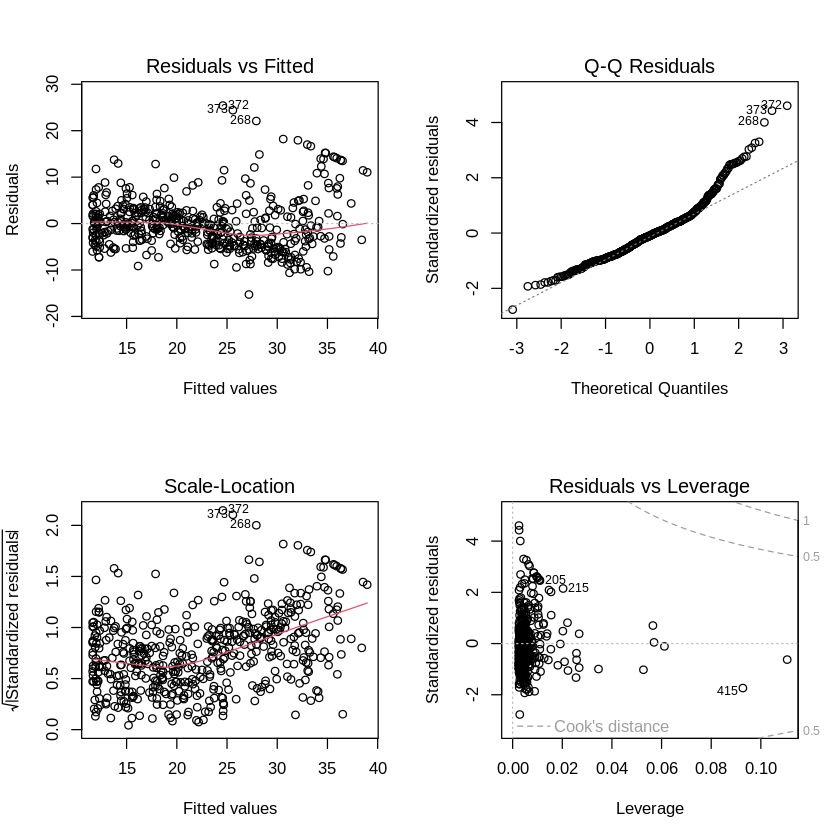

In [21]:
par(mfrow = c(2, 2))
plot(lm.fit2)


... vemos que quando o termo `lstat^2` é incluído no modelo, não há um padrão discernível nos resíduos.

Para criar um ajuste cúbico, podemos incluir um preditor da forma `I(x^3)`. No entanto, essa abordagem pode começar a se tornar difícil de gerenciar para polinômios de ordem superior. Uma abordagem melhor envolve o uso da função `poly()` para criar o polinômio dentro de `lm()`. Por exemplo, o seguinte comando produz um ajuste polinomial de quinta ordem:


In [22]:
lm.fit5 <- lm(medv ~ poly(lstat, 5))
summary(lm.fit5)



Call:
lm(formula = medv ~ poly(lstat, 5))

Residuals:
     Min       1Q   Median       3Q      Max 
-13.5433  -3.1039  -0.7052   2.0844  27.1153 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)       22.5328     0.2318  97.197  < 2e-16 ***
poly(lstat, 5)1 -152.4595     5.2148 -29.236  < 2e-16 ***
poly(lstat, 5)2   64.2272     5.2148  12.316  < 2e-16 ***
poly(lstat, 5)3  -27.0511     5.2148  -5.187 3.10e-07 ***
poly(lstat, 5)4   25.4517     5.2148   4.881 1.42e-06 ***
poly(lstat, 5)5  -19.2524     5.2148  -3.692 0.000247 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.215 on 500 degrees of freedom
Multiple R-squared:  0.6817,	Adjusted R-squared:  0.6785 
F-statistic: 214.2 on 5 and 500 DF,  p-value: < 2.2e-16


O resultado sugere que incluir termos polinomiais adicionais (até a quinta ordem, nesse caso) leva a uma melhoria no ajuste do modelo! No entanto, uma investigação mais profunda dos dados revelaria que nenhum termo polinomial além da quinta ordem tem valores de $p$ significativos em um ajuste de regressão (você pode testar isso utilizando `poly(lstat, 6))`, por exemplo).

Por padrão, a função `poly()` *ortogonaliza* os preditores: isso significa que as variáveis passadas por essa função são transformadas. (Você pode pesquisar o que isso significa, mas de forma geral, um conjunto de variáveis é ortogonal se cada par de variáveis distintas no conjunto tiver covariância igual a zero.) No entanto, os resultados de um modelo linear aplicado à saída da função `poly()` (i.e., baseados em preditores "ortogonalizados") terá a mesma significância/interpretação de um modelo linear aplicado aos polinômios "brutos" (embora as estimativas dos coeficientes sejam diferentes devido à ortogonização). Para utilizar os polinômios "brutos" com a função `poly()`, o argumento `raw = TRUE` deve ser utilizado. Note as diferenças a seguir:


In [23]:
lm.fit6 <- lm(medv ~ poly(lstat, 3))
summary(lm.fit6)
lm.fit7 <- lm(medv ~ I(lstat^1)+I(lstat^2)+I(lstat^3))
summary(lm.fit7)
lm.fit8 <- lm(medv ~ poly(lstat, 3, raw = TRUE))
summary(lm.fit8)



Call:
lm(formula = medv ~ poly(lstat, 3))

Residuals:
     Min       1Q   Median       3Q      Max 
-14.5441  -3.7122  -0.5145   2.4846  26.4153 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)       22.5328     0.2399  93.937  < 2e-16 ***
poly(lstat, 3)1 -152.4595     5.3958 -28.255  < 2e-16 ***
poly(lstat, 3)2   64.2272     5.3958  11.903  < 2e-16 ***
poly(lstat, 3)3  -27.0511     5.3958  -5.013 7.43e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.396 on 502 degrees of freedom
Multiple R-squared:  0.6578,	Adjusted R-squared:  0.6558 
F-statistic: 321.7 on 3 and 502 DF,  p-value: < 2.2e-16



Call:
lm(formula = medv ~ I(lstat^1) + I(lstat^2) + I(lstat^3))

Residuals:
     Min       1Q   Median       3Q      Max 
-14.5441  -3.7122  -0.5145   2.4846  26.4153 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 48.6496253  1.4347240  33.909  < 2e-16 ***
I(lstat^1)  -3.8655928  0.3287861 -11.757  < 2e-16 ***
I(lstat^2)   0.1487385  0.0212987   6.983 9.18e-12 ***
I(lstat^3)  -0.0020039  0.0003997  -5.013 7.43e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.396 on 502 degrees of freedom
Multiple R-squared:  0.6578,	Adjusted R-squared:  0.6558 
F-statistic: 321.7 on 3 and 502 DF,  p-value: < 2.2e-16



Call:
lm(formula = medv ~ poly(lstat, 3, raw = TRUE))

Residuals:
     Min       1Q   Median       3Q      Max 
-14.5441  -3.7122  -0.5145   2.4846  26.4153 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 48.6496253  1.4347240  33.909  < 2e-16 ***
poly(lstat, 3, raw = TRUE)1 -3.8655928  0.3287861 -11.757  < 2e-16 ***
poly(lstat, 3, raw = TRUE)2  0.1487385  0.0212987   6.983 9.18e-12 ***
poly(lstat, 3, raw = TRUE)3 -0.0020039  0.0003997  -5.013 7.43e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.396 on 502 degrees of freedom
Multiple R-squared:  0.6578,	Adjusted R-squared:  0.6558 
F-statistic: 321.7 on 3 and 502 DF,  p-value: < 2.2e-16


Podemos utilizar outros tipos de transformações dos preditores. Por exemplo, aqui tentamos uma transformação logarítmica:



In [24]:
summary(lm(medv ~ log(rm), data = Boston))




Call:
lm(formula = medv ~ log(rm), data = Boston)

Residuals:
    Min      1Q  Median      3Q     Max 
-19.487  -2.875  -0.104   2.837  39.816 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -76.488      5.028  -15.21   <2e-16 ***
log(rm)       54.055      2.739   19.73   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.915 on 504 degrees of freedom
Multiple R-squared:  0.4358,	Adjusted R-squared:  0.4347 
F-statistic: 389.3 on 1 and 504 DF,  p-value: < 2.2e-16


## Preditores Qualitativos

Agora examinaremos o conjunto de dados `Carseats`, que faz parte da
biblioteca `ISLR2`. Tentaremos prever `Sales` (vendas de cadeirinhas de carro para crianças) em $400$ locais com base em vários preditores.


In [25]:
head(Carseats)



,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>,<fct>
1,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
2,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
3,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
4,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
5,4.15,141,64,3,340,128,Bad,38,13,Yes,No
6,10.81,124,113,13,501,72,Bad,78,16,No,Yes


Os dados de `Carseats` incluem preditores qualitativos, como `shelveloc`, um indicador da qualidade da localização das prateleiras—ou seja, o espaço dentro de uma loja onde a cadeirinha é exibida—em cada local. O preditor `shelveloc` pode assumir três valores possíveis: *Bad*, *Medium* e *Good*. Dado uma variável qualitativa como `shelveloc`, o `R` gera variáveis *dummy* (i.e., copostas de $0$s ou $1$s) automaticamente. Abaixo, ajustamos um modelo de regressão múltipla que inclui alguns termos de interação:



In [26]:
lm.fit <- lm(Sales ~ . + Income:Advertising + Price:Age, data = Carseats) # Ajusta modelo com todas as variáveis e duas interações específicas
summary(lm.fit)



Call:
lm(formula = Sales ~ . + Income:Advertising + Price:Age, data = Carseats)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.9208 -0.7503  0.0177  0.6754  3.3413 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)         6.5755654  1.0087470   6.519 2.22e-10 ***
CompPrice           0.0929371  0.0041183  22.567  < 2e-16 ***
Income              0.0108940  0.0026044   4.183 3.57e-05 ***
Advertising         0.0702462  0.0226091   3.107 0.002030 ** 
Population          0.0001592  0.0003679   0.433 0.665330    
Price              -0.1008064  0.0074399 -13.549  < 2e-16 ***
ShelveLocGood       4.8486762  0.1528378  31.724  < 2e-16 ***
ShelveLocMedium     1.9532620  0.1257682  15.531  < 2e-16 ***
Age                -0.0579466  0.0159506  -3.633 0.000318 ***
Education          -0.0208525  0.0196131  -1.063 0.288361    
UrbanYes            0.1401597  0.1124019   1.247 0.213171    
USYes              -0.1575571  0.1489234  -1.058 0.290729    
Inco

A função `contrasts()` retorna a codificação que o `R` usa para as variáveis *dummy* (use `?contrasts` para aprender sobre outras formas de utilizar essa função`):



In [27]:
attach(Carseats)
contrasts(ShelveLoc)


,Good,Medium
Bad,0,0
Good,1,0
Medium,0,1


Vemos no *output* acima que o `R` criou uma variável *dummy* chamada `ShelveLocGood`, que assume o valor $1$ se a localização das prateleiras for *Good*, e $0$ caso contrário. Também foi criada uma variável dummy chamada `ShelveLocMedium`, que é igual a $1$ se a localização das prateleiras for *Medium*, e $0$ caso contrário. Uma localização *Bad* para prateleiras corresponde a $0$ para ambas as variáveis *dummy*.

O fato de o coeficiente para `ShelveLocGood` na saída de regressão ser positivo indica que uma boa localização para prateleiras está associada a vendas mais altas (em relação a uma localização *Bad*). E `ShelveLocMedium` tem um coeficiente positivo menor, indicando que uma localização média para prateleiras também está associada a vendas mais altas do que uma localização *Bad*, mas menores do que as vendas de uma localização *Good*.


## Inspeção de Violação de Suposições de Modelos Lineares

Vamos focar agora no diagnóstico e inspeção de violações de suposições de modelos lineares. O diagnóstico de modelos é crucial, pois a estimação de parâmetros, os valores $p$ e os intervalos de confiança dependem da não violação de suposições sobre modelos e dados. Se as suposições forem violadas, as estimativas podem ser estatisticamente significativas mesmo que o efeito real em estudo seja *nulo*.

Diferentes tipos de modelos requerem diferentes verificações. Por exemplo, assume-se que resíduos normalmente distribuídos se aplicam à regressão linear, mas essa não é uma suposição apropriada para a regressão logística. Além disso, recomenda-se realizar inspeções visuais, ou seja, gerar e inspecionar os chamados *gráficos de diagnóstico*. É importante considerar que testes estatísticos formais são frequentemente muito rigorosos e podem alertar para violação de suposições mesmo quando tudo esteja dentro de uma certa "faixa de tolerância".

Para a versão deste tutorial que utiliza o `R` instalado no computador, a função `check_model()` do pacote `performance` é utilizada para entender como esses gráficos de diagnóstico devem ser interpretados e, se violações forem detectadas, como corrigi-las de forma geral. Aqui, faremos o mesmo, mas sem o uso do pacote `performance`. Isso porque esse pacote infelizmente não funciona no **Google Colab** atualmente. Utilizaremos então pacotes alternativos. Começamos com um exemplo simples para um modelo linear basedo nos dados `iris`:


In [28]:
data(iris)
m1 <- lm(Sepal.Width ~ Species + Petal.Length + Petal.Width, data = iris)

#### ***Relação Linear***

O gráfico que plotaremos a seguir ajuda a verificar a suposição de relação linear. Ele mostra se os preditores podem ter uma relação não linear com o resultado. Uma linha (vermelha) reta e horizontal, como no exemplo abaixo, indica que o modelo parece não ter problema em relação à linearidade:


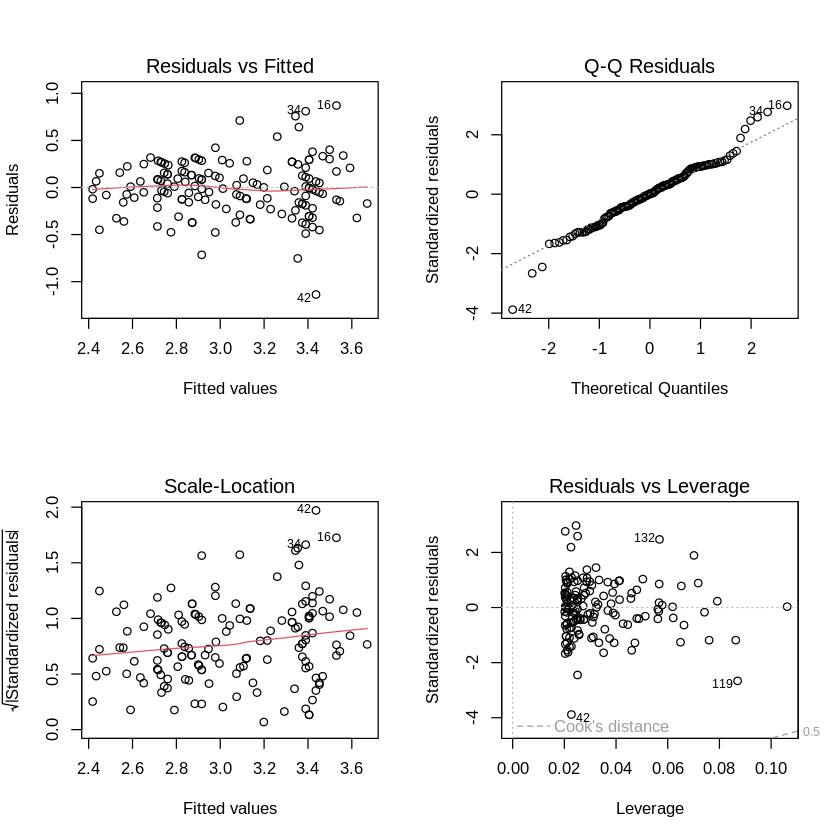

In [29]:
par(mfrow = c(2, 2)) # para que os 4 gráficos do `plot()` apareçam juntos
plot(m1)
par(mfrow = c(1, 1)) # para voltar à configuração padrão do `plot()` (1 gráfico por janela)



Agora vamos ver um exemplo diferente, onde simulamos dados com uma relação *quadrática* de um dos preditores, violando a suposição do modelo linear:



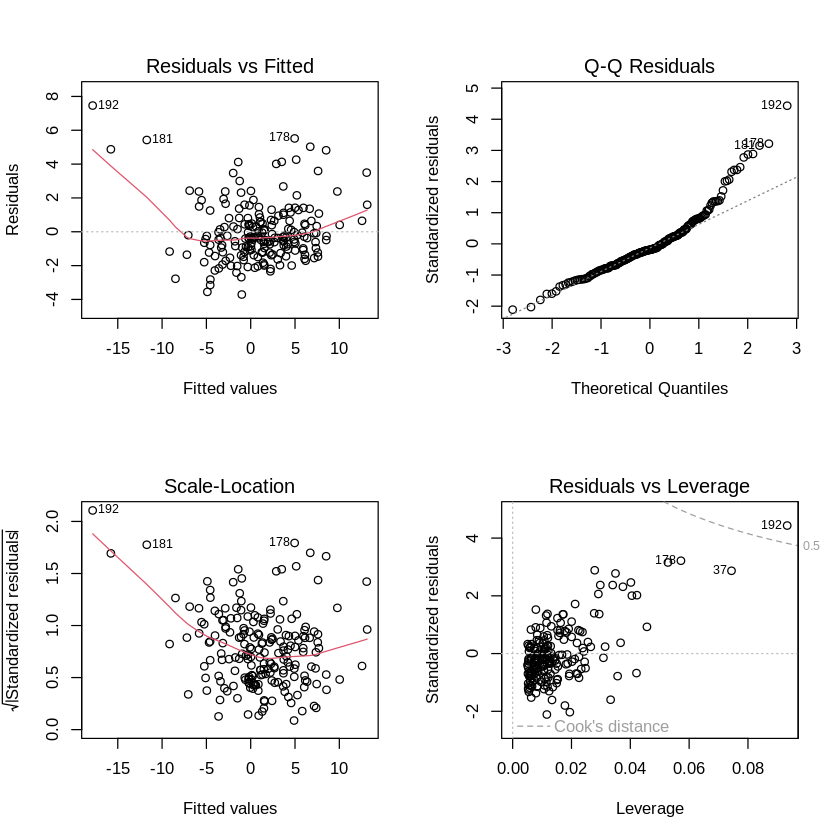

In [30]:
set.seed(1234) # Define a `seed` de geração de números aleatórios para reprodutibilidade
x <- rnorm(200) # Gera 200 números com distribuição normal padrão para a variável x
z <- rnorm(200) # Gera 200 números com distribuição normal padrão para a variável z
# relação quadrática
y <- 2 * x + x^2 + 4 * z + rnorm(200) # Cria a variável resposta y com uma relação não linear em x
d <- data.frame(x, y, z) # Organiza as variáveis em um dataframe
m <- lm(y ~ x + z, data = d) # Ajusta um modelo linear simples (subestimando a relação real)

par(mfrow = c(2, 2)) # para que os 4 gráficos do `plot()` apareçam juntos
plot(m)
par(mfrow = c(1, 1)) # para voltar à configuração padrão do `plot()` (1 gráfico por janela)

*Como corrigir isso?* Se as linhas de referência vermelhas não forem aproximadamente plana e horizontal, isso pode indicar que alguns dos preditores provavelmente deveriam ser modelados como um termo quadrático. Transformar a variável resposta pode ser outra solução quando as suposições de linearidade não são atendidas:



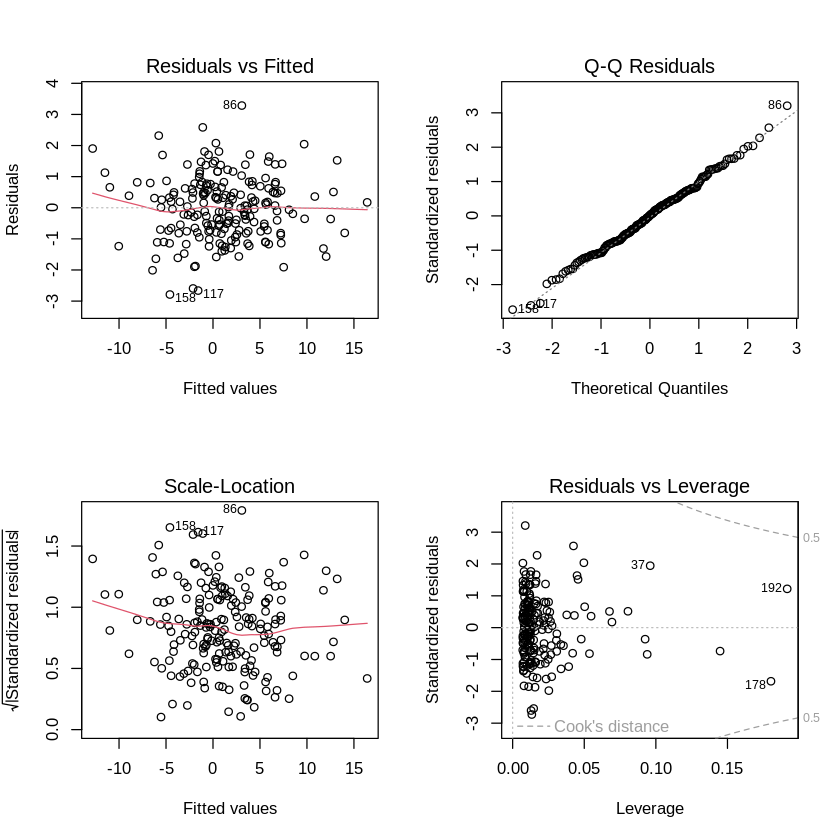

In [31]:
# modelar termo quadrático
m <- lm(y ~ x + I(x^2) + z, data = d) # Ajusta o modelo incluindo o termo quadrático de x
par(mfrow = c(2, 2)) # para que os 4 gráficos do `plot()` apareçam juntos
plot(m)
par(mfrow = c(1, 1)) # para voltar à configuração padrão do `plot()` (1 gráfico por janela)


#### ***Heteroscedasticidade***

Vamos focar agora na homogeneidade da variância (detecção de heteroscedasticidade). O gráfico a seguir ajuda a verificar a suposição de variância igual (ou constante), ou seja, homoscedasticidade. Para atender a essa suposição, a variância dos resíduos em diferentes valores dos preditores deve ser semelhante e não aumentar nem diminuir notavelmente. Portanto, o padrão desejado seria que os pontos se espalhassem igualmente acima e abaixo de uma linha aproximadamente reta e horizontal, sem nenhum desvio aparente.

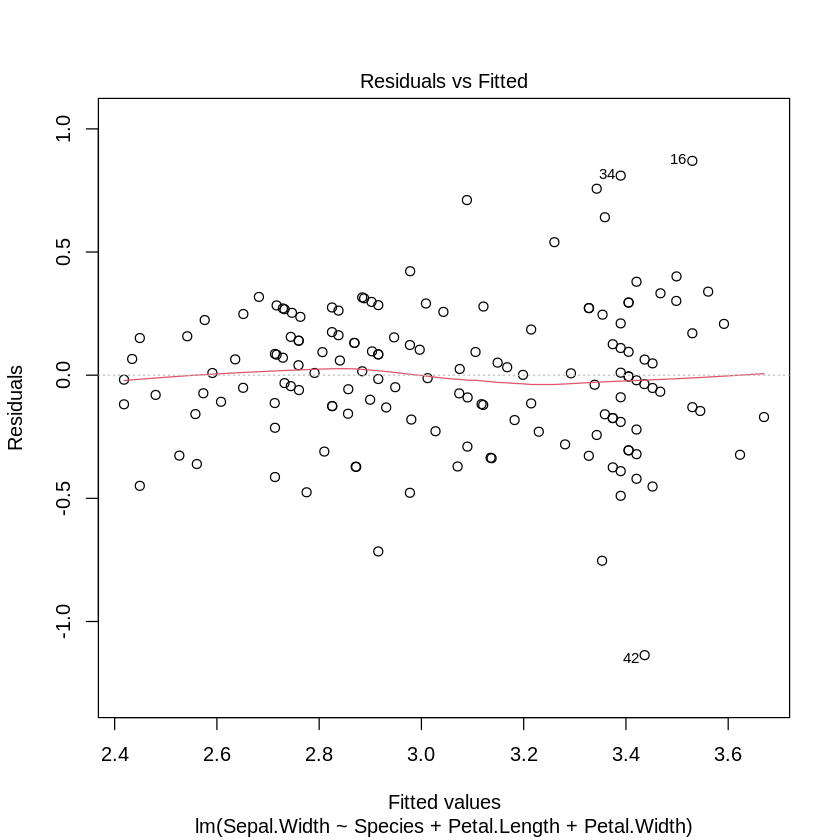

In [32]:
plot(m1, which = c(1))


Além da interpretação visual, o teste de *Breusch-Pagan* é um teste formal e popular para detectar heteroscedasticidade. Ele testa se a variância dos erros depende das variáveis preditoras e pode ser executado no `R` com a função `bptest()` do pacote `lmtest` (instale o pacote se necessário):



In [33]:
library(lmtest)
bptest(m1)


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  m1
BP = 9.3021, df = 4, p-value = 0.05398


Com um valor-$p$ de $0{,}054$, estamos muito próximos do nível de significância comumente adoptado de $0{,}05$. Isso implica que, se adotarmos $α = 0{,}05$, não rejeitamos a *hipótese nula* de homocedasticidade, ou seja: não há evidência estatisticamente significativa de heterocedasticidade. (Note que a *hipótese alternativa* do teste de Breusch-Pagan é de heterocedasticidade, e a hipótese nula é de homocedasticidade.) Porém, o valor está bem próximo de $0,05$, então é um caso limítrofe...

O teste de *White* é outro teste popular de heteroscedasticidade. Ele não assume uma forma específica para a relação entre a variância dos erros e os preditore e pode ser executado no `R` com a função `ncvTest()` do pacote `car` (instale o pacote se necessário):


In [34]:
library(car)
ncvTest(m1)


Non-constant Variance Score Test 
Variance formula: ~ fitted.values 
Chisquare = 13.46205, Df = 1, p = 0.00024344

Nesse caso, como o valor-$p$ é muito pequeno ($p < 0.001$), rejeitamos a hipótese nula, ou seja: há evidência estatisticamente significativa de heterocedasticidade no modelo.

*Como corrigir isso?* Existem várias maneiras de abordar a heteroscedasticidade, mas como elas são um pouco complicadas, não vamos entrar em detalhes aqui. Elas incluem: calcular erros padrão consistentes com heteroscedasticidade, por exemplo, utilizando `parameters::model_parameters(m1, vcov = "HC3")`; modelar a heteroscedasticidade diretamente, por exemplo, usando o pacote `glmmTMB` e uma "fórmula de dispersão"; simplesmente transformar a variável resposta, por exemplo, aplicando a função `log()`; entre outras.


#### ***Multicolinearidade***

A seguir vamos examinar a questão da multicolinearidade: onde há um alto grau de correlação entre variáveis independentes, o que pode dificultar o isolamento dos efeitos individuais de cada variável (devido à redundância de informação entre elas). A tabela a seguir verifica a potencial colinearidade entre os preditores baseado em VIF (*Variance Inflation Factor*):


In [35]:
vif(m1)



,GVIF,Df,GVIF^(1/(2*Df))
Species,22.84317,2,2.186196
Petal.Length,22.28750,1,4.720964
Petal.Width,18.37362,1,4.286446


O fator de inflação da variância (VIF) indica a magnitude da multicolinearidade dos termos do modelo. Os limiares para colinearidade baixa, moderada e alta são valores de VIF inferiores a $5$, entre $5$ e $10$ e superiores a $10$, respectivamente. Note que esses limiares, embora comumente usados, também são criticados por serem muito altos. Alguns estatísticos sugerem o uso de valores mais baixos, por exemplo, um VIF igual a $3$ ou maior já pode não ser mais considerado como "baixo".

Para as variáveis contínuas `Petal.Length` e `Petal.Width`, o **GVIF** é igual ao VIF. Isso ocorre porque cada uma dessas variáveis consome apenas 1 grau de liberdade (Df = 1) no modelo. Para `Species`, que utiliza múltiplos graus de liberdade, devemos observar o valor de **GVIF^(1/(2*Df))**. Este valor funciona como um VIF "padronizado" ou "efetivo", permitindo a comparar a multicolinearidade de `Species` de forma justa com a das outras variáveis contínuas. Vemos que nosso modelo claramente sofre de multicolinearidade.

*Como corrigir isso?* Geralmente, os preditores com valores de VIF (muito) altos devem ser removidos do modelo para corrigir a multicolinearidade. É necessário ter alguma cautela com termos de interação: se eles estiverem incluídos em um modelo, provavelmente os valores de VIF serão naturalmente altos.


#### ***Normalidade dos Resíduos***

Em regressão linear, os resíduos devem ser normalmente distribuídos. Isso pode ser verificado usando o chamado gráfico Q-Q (*Quantile-Quantile plot*), para comparar as formas das distribuições. Este gráfico mostra os quantis dos resíduos studentizados *versus* os quantis teórico.

Geralmente, os pontos devem cair ao longo da linha de referência pontilhada. Se houver algum desvio (principalmente nas caudas), isso indica que o modelo não prevê bem o resultado para a faixa que mostra maiores desvios da linha de referência.


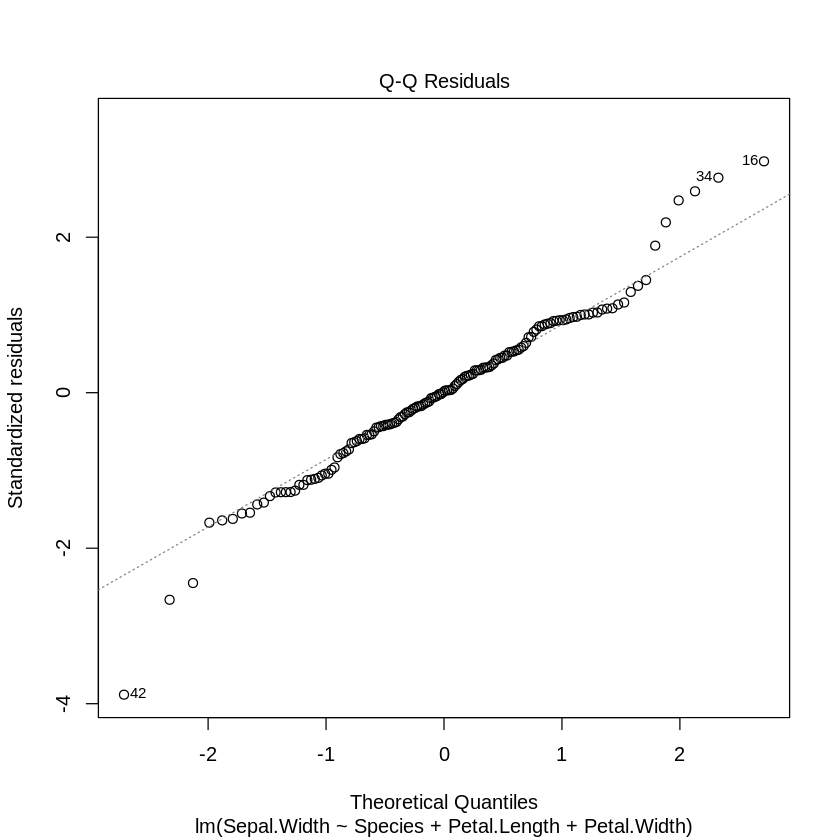

In [36]:
plot(m1, which = 2)



Em nosso exemplo, vemos que a maioria dos pontos de dados está ok, exceto algumas observações nas caudas. Se alguma ação é necessária para corrigir isso ou não, também pode depender dos resultados dos outros gráficos de diagnóstico. Se todos os outros gráficos não indicarem violação das suposições, algum desvio da normalidade, particularmente nas caudas, pode ser considerado menos crítico.

Além da interpretação visual, o teste de *Shapiro-Wilk* (entre outros) é um teste formal e popular para detectar normalidade dos resíduos:


In [37]:
shapiro.test(residuals(m1))




	Shapiro-Wilk normality test

data:  residuals(m1)
W = 0.97575, p-value = 0.009337


Segundo o teste, a *hipótese nula* é que os resíduos têm distribuição normal (portanto, a *hipótese alternativa* é que os resíduos não têm distribuição normal). Como o valor-$p$ é $0.009$, ou seja, menor que $0.05$, rejeitamos a hipótese nula. Isso indica que os resíduos não seguem uma distribuição normal.

A violação da normalidade afeta principalmente a confiabilidade dos valores-$p$ e intervalos de confiança dos coeficientes. As estimativas dos coeficientes em si não são afetados, mas as inferências estatísticas podem ser comprometidas.

*Como corrigir isso?* Sem entrar em detalhes, aqui estão alguns remédios para (tentar) corrigir a não normalidade dos resíduos: para tamanhos de amostra grandes, a suposição de normalidade pode ser relaxada devido ao teorema do limite central (nenhuma ação é necessária); calcular erros padrão consistentes com heteroscedasticidade pode ajudar; *bootstrap* pode ser alternativa para resolver problemas com resíduos não normalmente distribuídos (isso pode ser feito usando o pacote `parameters`, por exemplo, `parameters::model_parameters(m1, bootstrap = TRUE)` ou `parameters::bootstrap_parameters()`. (Vamos falar sobre *bootstrap* quando falarmos sobre *Florestas Aleatórias*.)



# Regressão Logística

## Dados do Mercado de Ações

Agora vamos examinar o conjunto de dados sobre o mercado de ações `Smarket` da biblioteca `ISLR2`. Este conjunto de dados contém rentabilidades percentuais do índice de ações S\&P 500 ao longo de $1250$ dias, desde o início de 2001 até o final de 2005. Cada coluna representa a rentabilidade percentual de cada um dos cinco dias de negociação anteriores, de `Lag1` a `Lag5` (ou seja, são *variáveis defasadas* ou *lagged variables*). Também foram registrados os dados de `Volume` (número de ações negociadas no dia anterior, em bilhões), `Today` (a rentabilidade percentual da data em questão) e `Direction` (se o mercado estava crescendo (`Up`) ou diminuindo (`Down`) nesta data). Nosso objetivo será prever `Direction` (uma resposta qualitativa) utilizando as outras variáveis.


[1] "Year"      "Lag1"      "Lag2"      "Lag3"      "Lag4"      "Lag5"     
[7] "Volume"    "Today"     "Direction"

[1] 1250    9

      Year           Lag1                Lag2                Lag3          
 Min.   :2001   Min.   :-4.922000   Min.   :-4.922000   Min.   :-4.922000  
 1st Qu.:2002   1st Qu.:-0.639500   1st Qu.:-0.639500   1st Qu.:-0.640000  
 Median :2003   Median : 0.039000   Median : 0.039000   Median : 0.038500  
 Mean   :2003   Mean   : 0.003834   Mean   : 0.003919   Mean   : 0.001716  
 3rd Qu.:2004   3rd Qu.: 0.596750   3rd Qu.: 0.596750   3rd Qu.: 0.596750  
 Max.   :2005   Max.   : 5.733000   Max.   : 5.733000   Max.   : 5.733000  
      Lag4                Lag5              Volume           Today          
 Min.   :-4.922000   Min.   :-4.92200   Min.   :0.3561   Min.   :-4.922000  
 1st Qu.:-0.640000   1st Qu.:-0.64000   1st Qu.:1.2574   1st Qu.:-0.639500  
 Median : 0.038500   Median : 0.03850   Median :1.4229   Median : 0.038500  
 Mean   : 0.001636   Mean   : 0.00561   Mean   :1.4783   Mean   : 0.003138  
 3rd Qu.: 0.596750   3rd Qu.: 0.59700   3rd Qu.:1.6417   3rd Qu.: 0.596750  
 Max. 

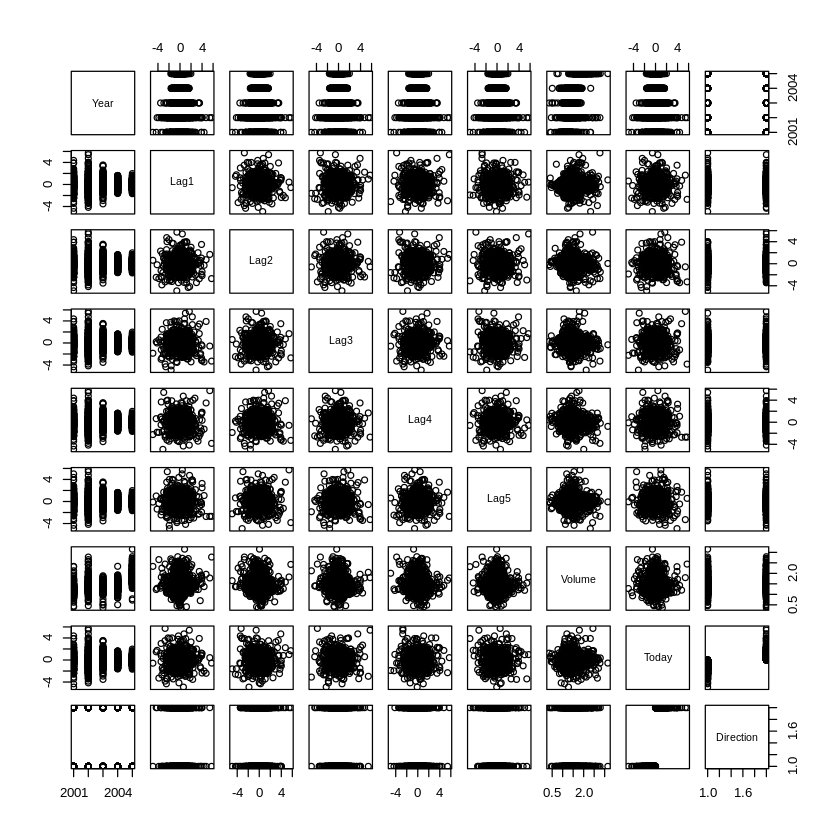

In [38]:
library(ISLR2) # Carrega a biblioteca que contém o dataset Smarket (Stock Market Data)
names(Smarket) # Lista os nomes das colunas (variáveis) do conjunto de dados
dim(Smarket) # Exibe as dimensões do dataset (número de linhas e colunas
summary(Smarket) # Gera um resumo estatístico (média, quartis, etc.) para cada variável
pairs(Smarket) # Cria uma matriz de gráficos de dispersão para visualizar correlações


A função `cor()` produz uma matriz que contém todas as correlações pareadas entre os preditores em um conjunto de dados. O primeiro comando abaixo gera uma mensagem de *erro* porque a variável `direction` é qualitativa:



In [39]:
cor(Smarket)

ERROR: Error in cor(Smarket): 'x' must be numeric


In [ ]:
cor(Smarket[, -9]) #removendo a variável `direction` (coluna 9 na nossa base de dados) resolve o problema


Como era de se esperar, as correlações entre as variáveis defasadas (`Lag...`) e os retornos de hoje (`Today`) são próximas de zero. Em outras palavras, parece haver pouca correlação entre os retornos de hoje e os retornos dos dias anteriores. A única correlação "relativamente substancial" é entre `Year` e `Volume`. Ao plotarmos os dados, que estão ordenados cronologicamente, vemos que o `Volume` está aumentando ao longo do tempo. Em outras palavras, o número médio de ações negociadas diariamente aumentou de 2001 a 2005.



In [ ]:
attach(Smarket)
plot(Volume)


## Ajustando uma Regressão Logística

Agora, vamos ajustar um modelo de regressão logística para prever `Direction` usando `Lag1` até `Lag5` e `Volume`. A função `glm()` pode ser usada para ajustar muitos tipos de modelos lineares generalizados, incluindo de regressão logística.

A sintaxe da função `glm()` é semelhante à do `lm()`, com a diferença de que devemos passar o argumento `family = binomial` para informar ao `R` que estamos ajustando uma regressão logística (em vez de algum outro tipo de modelo linear generalizado):


In [ ]:
glm.fits <- glm(
    Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume,
    data = Smarket, family = binomial ) # Ajusta um modelo de regressão logística
summary(glm.fits)


O menor valor de $p$ aqui está associado a `Lag1`. O coeficiente negativo para esse preditor sugere que, se o mercado teve um retorno positivo ontem, é menos provável que ele suba hoje. No entanto, com um valor de $0.15$, o valor de $p$ ainda é relativamente grande, e portanto, não há uma evidência clara de uma associação real entre `Lag1` e `Direction`.

Usamos a função `coef()` para acessar apenas os coeficientes deste modelo ajustado. Também podemos usar a função `summary()` para acessar aspectos específicos do modelo ajustado, como os valores $p$ dos coeficientes:


In [ ]:
coef(glm.fits)
summary(glm.fits)$coef # Extrai a matriz completa de coeficientes (estimativas, erro padrão, z e p-valor)
summary(glm.fits)$coef[, 4] # Extrai especificamente a quarta coluna, que contém os p-valores


A função `predict()` pode ser usada para prever a probabilidade de o mercado subir, dado os valores dos preditores. A opção `type = "response"` informa ao `R` para retornar as probabilidades estimadas de que a variável resposta seja igual a $1$ (ou $100\%$).

Se nenhum conjunto de dados for fornecido à função `predict()`, as probabilidades são calculadas para os dados que foram usados para ajustar o modelo. Abaixo, mostramos apenas as primeiras dez probabilidades. Sabemos que esses valores correspondem à probabilidade de o mercado subir, e não descer (porque a função `contrasts()` indica que o `R` criou uma variável dummy com valor $1$ para `Up`):


In [ ]:
glm.probs <- predict(glm.fits, type = "response") # Gera as probabilidades previstas (P(Y=1|X))
glm.probs[1:10] # Exibe as probabilidades de subida para as 10 primeiras observações
contrasts(Direction) # Mostra como o R codificou a variável categórica (quem é 0 e quem é 1)


Para fazer uma previsão sobre se o mercado subirá ou descerá em um determinado dia, devemos converter essas probabilidades previstas nos rótulos `Up` ou `Down`. Os seguintes dois comandos criam um vetor de previsões de classe com base em se a probabilidade estimada de um crescimento do mercado é maior ou menor que $0,5$:



In [ ]:
glm.pred <- ifelse(glm.probs > 0.5, "Up", "Down") # Converte probabilidades em previsões categóricas usando corte de 0.5



A função `ifelse()` verifica se a probabilidade é maior que $0,5$ e atribui a classe `"Up"` se for verdadeira e `"Down"` caso contrário. Podemos realizar a mesma computação utilizado o *script* abaixo:



In [ ]:
glm.pred <- rep("Down", 1250) # Cria um vetor preenchido com "Down" para todas as 1250 observações
glm.pred[glm.probs > 0.5] = "Up" # Substitui para "Up" apenas nos casos onde a probabilidade supera 0.5


O primeiro comando cria um vetor com $1250$ elementos de classe `Down`. A segunda linha transforma para `Up` todos os elementos cuja probabilidade prevista de crescimento do mercado excede $0,5$. Com base nessas previsões, podemos usar a função `table()` para gerar uma matriz de confusão, a fim de determinar quantas observações foram classificadas corretamente ou incorretamente:



In [ ]:
# Criando a matriz de confusão
confusion.matrix <- table(Predicted = glm.pred, Actual = Smarket$Direction) # Cria a matriz de confusão cruzando previsões e valores reais
confusion.matrix # Exibe a tabela de acertos e erros do modelo


A função `table()` cria uma tabela de contingência comparando as previsões (`glm.pred`) com os valores reais de `Direction` (o valor observado para a variável `Direction` de `Smarket`). A matriz de confusão resultante mostra o número de classificações corretas e incorretas para cada classe (`Up` e `Down`).

A partir da matriz de confusão, podemos calcular as métricas de desempenho do modelo, como acurácia, precisão, *recall* e *F1-score*, para avaliar o quão bem o modelo de regressão logística está classificando o mercado (vamos falar sobre essas métricas quando falarmos sobre validação de modelos):


In [ ]:
table(glm.pred, Direction) # Gera a matriz de confusão (frequências de acertos e erros)
(507 + 145) / 1250 # Calcula manualmente a acurácia somando a diagonal principal
mean(glm.pred == Direction) # Calcula a acurácia de forma automática e vetorizada


Os elementos diagonais da matriz de confusão indicam as previsões *corretas*, enquanto os elementos fora da diagonal representam as previsões *incorretas*. Assim, nosso modelo previu corretamente que o mercado subiria em $507$ dos $1250$ dias e que ele cairia em $145$ dos $1250$ dias, totalizando $652$ ($507 + 145$) previsões corretas em $1250$ dias. A função `mean()` pode ser utilizada para calcular a fração de dias para os quais a previsão foi correta. Neste caso, a regressão logística previu corretamente o movimento do mercado $52,2%$ das movimentações.

À primeira vista, parece que o modelo de regressão logística está funcionando um pouco melhor do que um palpite aleatório. No entanto, esse resultado é enganoso porque treinamos e testamos o modelo no mesmo conjunto de $1250$ observações. Em outras palavras, $100\%-52.2\%=47.8\%$ é a taxa de erro de *treinamento*, e a taxa de erro de treinamento tende a subestimar a taxa de erro de *teste*.

Para avaliar melhor a precisão do modelo de regressão logística neste contexto, podemos ajustar o modelo usando parte dos dados (i.e., *dados de treinamento*) e depois verificar como ele se sai na previsão dos dados retidos (i.e., *dados de teste*). Isso nos dará uma taxa de erro mais realista, no sentido de que, na prática, estaremos interessados no desempenho do modelo não nos dados que usamos para ajustá-lo, mas sim em dias futuros, para os quais os movimentos do mercado são desconhecidos.

Para implementar essa estratégia, primeiro criaremos um vetor correspondente às observações de 2001 a 2004. Em seguida, usaremos esse vetor para criar um conjunto de dados de teste com as observações de 2005:


In [ ]:
train <- (Year < 2005) # Cria um vetor lógico: TRUE para anos anteriores a 2005, FALSE para 2005
Smarket.2005 <- Smarket[!train, ] # Filtra o dataset: mantém apenas as linhas que NÃO estão no treino (ou seja, 2005)
dim(Smarket.2005) # Verifica as dimensões do conjunto de teste (deve ter 252 linhas)
Direction.2005 <- Direction[!train] # Cria um vetor com os resultados reais do mercado em 20


O objeto `train` é um vetor de $1250$ elementos, correspondendo às observações no nosso conjunto de dados. Os elementos do vetor que correspondem às observações anteriores a 2005 são definidos como `TRUE`, enquanto os que correspondem às observações de 2005 são definidos como `FALSE`.

O objeto `train` é um vetor *booleano*, pois seus elementos são `TRUE` e `FALSE`. Vetores booleanos podem ser usados para obter um subconjunto das linhas ou colunas de uma matriz. Por exemplo, o comando `Smarket[train, ]` selecionaria um subconjunto dos dados correspondendo apenas às datas anteriores a 2005, pois são essas para as quais os elementos de `train` são `TRUE`.

O símbolo `!` pode ser usado para inverter todos os elementos de um vetor booleano. Ou seja, `!train` é um vetor semelhante ao `train`, exceto que os elementos que são `TRUE` em `train` são trocados para `FALSE` em `!train`, e os elementos que são `FALSE` em `train` são trocados para `TRUE` em `!train`. Portanto, `Smarket[!train, ]` retorna um subconjunto dos dados contendo apenas as observações para as quais `train` é `FALSE`—ou seja, as observações de 2005. O *output* acima indica que existem 252 dessas observações.

Agora, ajustamos um modelo de regressão logística usando apenas o subconjunto das observações que correspondem às datas anteriores a 2005, utilizando o argumento `subset`. Em seguida, obtemos as probabilidades preditivas de o mercado de ações subir para cada um dos dias no nosso conjunto de testes—ou seja, para os dias de 2005:


In [ ]:
glm.fits <- glm(
    Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume,
    data = Smarket, family = binomial, subset = train ) # Treina o modelo usando apenas os dados históricos (2001-2004)
glm.probs <- predict(glm.fits, Smarket.2005,
    type = "response") # Gera probabilidades para os dados "não vistos" de 2005


Observe que treinamos e testamos nosso modelo em dois conjuntos de dados completamente separados: o treinamento foi realizado usando apenas as datas antes de 2005, e o teste foi realizado usando apenas as datas de 2005.

Finalmente, calculamos as previsões para 2005 e comparamos com os movimentos reais do mercado durante esse período:


In [ ]:
glm.pred <- rep("Down", 252) # Cria vetor com "Down" para os 252 dias de 2005
glm.pred[glm.probs > .5] <- "Up" # Classifica como "Up" se a probabilidade for > 0.5
table(glm.pred, Direction.2005) # Gera a matriz de confusão para os dados de teste (2005)
mean(glm.pred == Direction.2005) # Calcula a acurácia (taxa de acerto) em 2005
mean(glm.pred != Direction.2005) # Calcula a taxa de erro (1 - acurácia) em 2005


A notação `!=` significa *diferente de*, e, portanto, o último comando calcula a taxa de erro do conjunto de teste. Os resultados são bastante decepcionantes: a taxa de erro do teste é de $0,52$ (ou $52\%$), o que é pior do que um palpite aleatório! Claro, esse resultado não é muito surpreendente, dado que geralmente não se espera que seja possível usar os retornos dos dias anteriores para prever o desempenho futuro do mercado...

Lembramos que o modelo de regressão logística tinha valores $p$ muito insatisfatórios associados a todos os preditores, e que o menor valor $p$, embora não muito pequeno, correspondia a `Lag1`. Talvez, ao remover as variáveis que não parecem ser úteis para prever `Direction`, possamos obter um modelo mais eficaz. Afinal, usar preditores que não têm relação com a resposta tende a causar uma deterioração na taxa de erro do teste (já que tais preditores aumentam a *variância* sem uma diminuição correspondente no *viés*), e assim remover tais preditores pode resultar em uma melhoria.

Abaixo reajustamos a regressão logística usando apenas `Lag1` e `Lag2`, que pareciam ter o maior poder preditivo no modelo de regressão logística original:


In [ ]:
glm.fits <- glm(Direction ~ Lag1 + Lag2, data = Smarket,
    family = binomial, subset = train) # Ajusta o modelo usando apenas Lag1 e Lag2 (as variáveis mais promissoras)
glm.probs <- predict(glm.fits, Smarket.2005,
    type = "response") # Gera as probabilidades para o conjunto de teste (2005)
glm.pred <- rep("Down", 252) # Inicializa o vetor de previsões com "Down"
glm.pred[glm.probs > .5] <- "Up" # Define como "Up" onde a probabilidade é superior a 50%
table(glm.pred, Direction.2005) # Gera a matriz de confusão para o novo modelo
mean(glm.pred == Direction.2005) # Calcula a nova acurácia global
106 / (106 + 76) # Calcula a Precision (Precisão) para a classe "Up"


Agora os resultados parecem um pouco melhores: $56\%$ dos movimentos diários foram corretamente previstos. Vale ressaltar que, neste caso, uma estratégia muito mais simples de prever que o mercado irá subir todos os dias também estará correta $56\%$ do tempo. Portanto, em termos de taxa de erro geral, o método de regressão logística não é melhor do que a "abordagem ingênua". No entanto, a matriz de confusão mostra que, nos dias em que a regressão logística prevê um aumento no mercado, a taxa de acerto é de $58\%$. Isso sugere uma possível estratégia de negociação: comprar nos dias em que o modelo prevê um aumento no mercado e evitar negociações nos dias em que uma queda é prevista. Claro, seria necessário investigar mais cuidadosamente se essa pequena melhoria é real ou apenas fruto do acaso...

Suponha que queiramos prever os retornos associados a valores específicos de `Lag1` e `Lag2`. Em particular, queremos prever `Direction` em um dia em que `Lag1` e `Lag2` sejam iguais a $1,2$ e $1,1$, respectivamente, e em um dia em que eles sejam iguais a $1,5$ e $-0,8$. Podemos fazer isso usando a função `predict()` da seguinte forma:


In [ ]:
predict(glm.fits,
    newdata =
      data.frame(Lag1 = c(1.2, 1.5),  Lag2 = c(1.1, -0.8)),
    type = "response" ) # Prediz a probabilidade de alta para dois novos cenários de mercado


## Exercício

Agora é sua vez de ajustar modelos de regressão a um novo conjunto de dados. Você pode fazer isso utilizando seus próprios dados, dados disponíveis na internet ou em pacotes do `R`. Outra opção é utilizar os dados sobre desmatamento municipal em 2004, disponíveis em https://thaleswest.wixsite.com/home/tutorials (note que o site contém a descrição das variáveis deste conjunto de dados).

Siga os seguintes passos:

- Primeiro, faça uma inspeção geral dos dados a serem utilizados.
- Selecione uma variável dependente e ao menos $5$ variáveis independentes para ajustar um modelo linear.
- Realize ao menos uma transformação das variáveis utilizadas em seu modelo.
- Inspecione possíveis violações das suposições de modelos lineares para o seu modelo.
- Faça o mesmo para ajustar um modelo logístico.
